# Station-MAE — Results Analysis

Two parts:
- **Part A** — Metrics from CSV files (no GPU needed, runs anywhere)
- **Part B** — Deep-dive inference: per-station gap-filling, station maps, temporal predictions

In [1]:
# ── Configuration ────────────────────────────────────────────────────────────
# Update these paths before running

CHECKPOINT  = "checkpoints/best.ckpt"   # trained model (Part B)
RESULTS_DIR = "test_results"            # from run_test_cloud.sh (Part A)
SAVE_FIGS   = True                                    # save plots to results dir

# tw12-d1024-v2 was trained BEFORE per-station normalisation was introduced,
# so Part B must normalise with GLOBAL per-variable stats (like --global_norm
# in run_test_cloud.sh).  Set False for newer runs (e.g. tw6-d1024-v3).
GLOBAL_NORM = True

# PeakWeather data root — first existing path wins; the last entry is used as
# a download target if none exist (the peakweather API auto-downloads from HF).
import os, sys
_CANDIDATE_ROOTS = [
    "/home/renku/work/PeakWeatherDataset",            # Renku cloud
    os.path.expanduser("~/PeakWeatherDataset"),       # local copy
    "PeakWeatherDataset",                             # inside project folder
]
DATA_ROOT = next((p for p in _CANDIDATE_ROOTS if os.path.isdir(p)), _CANDIDATE_ROOTS[-1])

sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from pathlib import Path

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
RESULTS_DIR = Path(RESULTS_DIR)
print("Results dir :", RESULTS_DIR.resolve())
print("Data root   :", DATA_ROOT, "(exists)" if os.path.isdir(DATA_ROOT)
      else "(missing — will be downloaded by peakweather on first Part B run)")

Results dir : /Users/aureliedejong/PycharmProjects/weather-station-model-with-transformers/Station MAE/test_results
Data root   : PeakWeatherDataset (exists)


## Part A — Metrics from CSV


In [2]:
# ── Load all CSV files ────────────────────────────────────────────────────────
def load_csv(name):
    path = list(RESULTS_DIR.rglob(name))
    if not path:
        print(f"  [skip] {name} not found")
        return None
    return pd.read_csv(path[0])

df_test    = load_csv("test_metrics.csv")
df_gap     = load_csv("gap_filling_metrics.csv")
df_lead1   = load_csv("lead1_metrics.csv")
df_persist = load_csv("persistence_metrics.csv")

print("Loaded:", [n for n, d in [("test", df_test), ("gap", df_gap),
                                   ("lead1", df_lead1), ("persist", df_persist)] if d is not None])

Loaded: ['test', 'gap', 'lead1', 'persist']


In [3]:
# ── 1. Per-variable summary table ─────────────────────────────────────────────
VARS   = ["temperature", "pressure", "humidity", "wind_u", "wind_v"]
UNITS  = {"temperature": "°C", "pressure": "hPa", "humidity": "%",
           "wind_u": "m/s", "wind_v": "m/s"}

if df_test is not None:
    row = df_test.iloc[0]
    rows = []
    for v in VARS:
        rmse_phys = row.get(f"{v}_rmse", float("nan"))
        mae_phys  = row.get(f"{v}_mae",  float("nan"))
        rmse_norm = row.get(f"{v}_norm_rmse", float("nan"))
        bias      = row.get(f"{v}_bias", float("nan"))
        r2        = row.get(f"{v}_norm_r2", float("nan"))
        # persistence comparison
        p_rmse = None
        if df_persist is not None:
            pr = df_persist[df_persist["metric"] == f"persist_{v}_rmse_norm"]
            p_rmse = float(pr["value"].values[0]) if len(pr) else float("nan")
            skill = 1 - rmse_norm / p_rmse if p_rmse and p_rmse > 0 else float("nan")
        else:
            skill = row.get(f"skill_{v}", float("nan"))
        rows.append({"Variable": v, "Unit": UNITS[v],
                     "RMSE": rmse_phys, "MAE": mae_phys,
                     "Bias": bias, "R²": r2, "Skill vs persist.": skill})
    summary = pd.DataFrame(rows).set_index("Variable")
    display(summary.style.format({
        "RMSE": "{:.4f}", "MAE": "{:.4f}", "Bias": "{:+.4f}",
        "R²": "{:.3f}", "Skill vs persist.": "{:+.3f}"
    }).background_gradient(subset=["RMSE"], cmap="RdYlGn_r")
      .background_gradient(subset=["Skill vs persist."], cmap="RdYlGn"))

,Unit,RMSE,MAE,Bias,R²,Skill vs persist.
Variable,,,,,,
temperature,°C,2.8030,2.2375,-0.2221,0.866,-0.063
pressure,hPa,6.1157,4.7578,+0.4939,0.870,-1.503
humidity,%,18.7092,15.5345,-5.2422,-0.023,-0.417
wind_u,m/s,1.7710,1.2876,+0.2635,0.351,+0.120
wind_v,m/s,1.8283,1.3250,-0.4812,0.259,+0.072


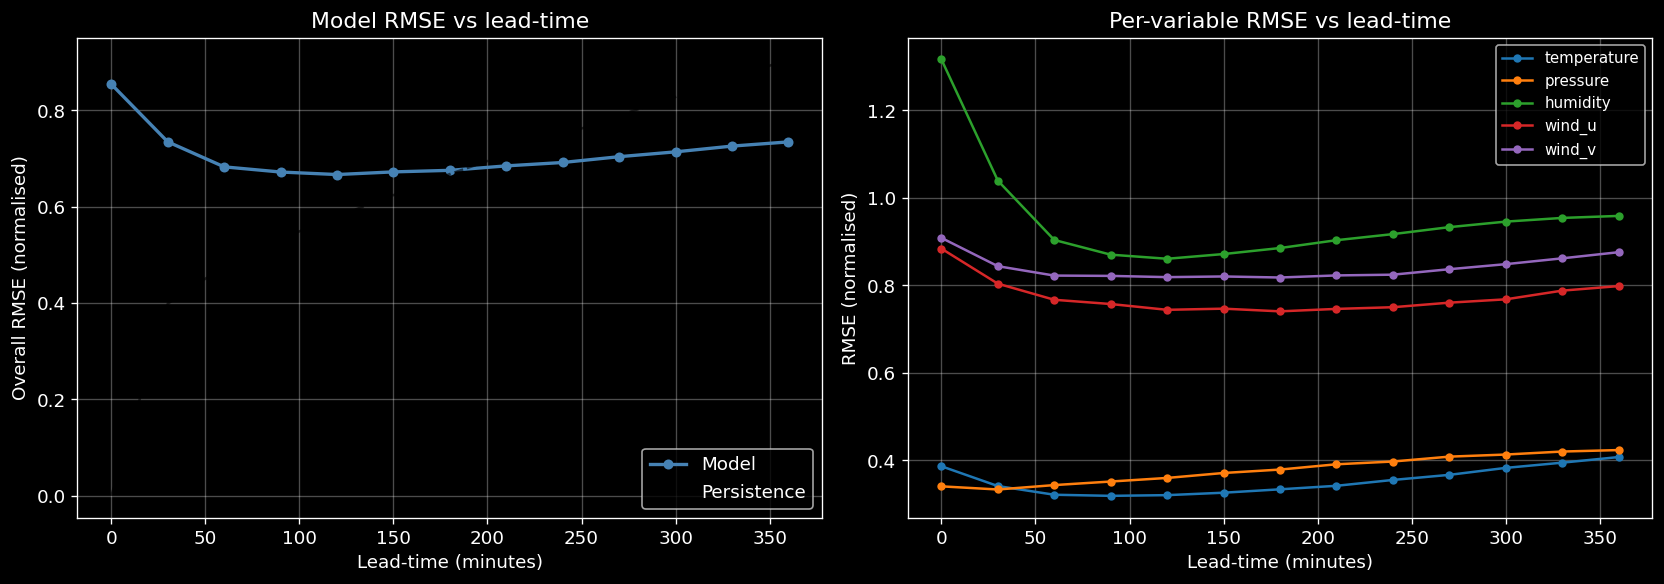

In [4]:
# ── 2. RMSE vs lead-time curve ─────────────────────────────────────────────────
if df_test is not None:
    row = df_test.iloc[0]

    # Extract per-delta metrics
    delta_keys = sorted(
        [k for k in row.index if k.startswith("delta_") and k.endswith("_overall_rmse_norm")],
        key=lambda k: int(k.split("_")[1])
    )
    deltas_min = [int(k.split("_")[1]) * 10 for k in delta_keys]
    model_rmse = [float(row[k]) for k in delta_keys]

    # Persistence per delta
    persist_rmse = []
    if df_persist is not None:
        for k in delta_keys:
            d = int(k.split("_")[1])
            pr = df_persist[df_persist["metric"] == f"persist_delta_{d:02d}_overall_rmse_norm"]
            persist_rmse.append(float(pr["value"].values[0]) if len(pr) else float("nan"))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Overall RMSE vs lead-time
    ax = axes[0]
    ax.plot(deltas_min, model_rmse, "o-", color="steelblue", lw=2, ms=5, label="Model")
    if persist_rmse:
        ax.plot(deltas_min, persist_rmse, "k--", lw=1.5, alpha=0.6, label="Persistence")
    ax.set_xlabel("Lead-time (minutes)")
    ax.set_ylabel("Overall RMSE (normalised)")
    ax.set_title("Model RMSE vs lead-time")
    ax.legend()
    ax.grid(alpha=0.3)

    # Per-variable RMSE at each delta
    ax = axes[1]
    colors = plt.cm.tab10.colors
    for vi, v in enumerate(VARS):
        var_keys = [k.replace("overall", v) for k in delta_keys]
        var_rmse = [float(row.get(k.replace("overall_rmse_norm", f"{v}_rmse_norm"),
                                  float("nan")))
                    for k in delta_keys]
        ax.plot(deltas_min, var_rmse, "o-", color=colors[vi], lw=1.5, ms=4, label=v)
    ax.set_xlabel("Lead-time (minutes)")
    ax.set_ylabel("RMSE (normalised)")
    ax.set_title("Per-variable RMSE vs lead-time")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    if SAVE_FIGS:
        fig.savefig(RESULTS_DIR / "delta_rmse_analysis.png", bbox_inches="tight")
    plt.show()

In [5]:
# ── 3. Gap-filling summary ─────────────────────────────────────────────────────
if df_gap is not None:
    row_g = df_gap.iloc[0]
    rows_g = []
    for v in VARS:
        rows_g.append({
            "Variable": v,
            "RMSE (norm)": row_g.get(f"gap_{v}_norm_rmse", float("nan")),
            "RMSE (phys)": row_g.get(f"gap_{v}_rmse",      float("nan")),
            "MAE (phys)":  row_g.get(f"gap_{v}_mae",       float("nan")),
            "Bias":        row_g.get(f"gap_{v}_bias",      float("nan")),
            "R²":          row_g.get(f"gap_{v}_norm_r2",   float("nan")),
        })
    df_gap_summary = pd.DataFrame(rows_g).set_index("Variable")
    print(f"Gap-filling — masked stations only  "
          f"(n_evals={int(row_g.get('gap_n_masked_evals', 0)):,})")
    display(df_gap_summary.style.format("{:.4f}")
            .background_gradient(subset=["RMSE (norm)"], cmap="RdYlGn_r")
            .background_gradient(subset=["R²"], cmap="RdYlGn"))

Gap-filling — masked stations only  (n_evals=337,491)


,RMSE (norm),RMSE (phys),MAE (phys),Bias,R²
Variable,,,,,
temperature,0.4054,3.2180,2.5924,0.7491,0.8385
pressure,0.3207,10.9193,2.9524,-1.8165,0.9066
humidity,1.2458,24.2276,20.8407,-15.2484,-0.3856
wind_u,0.9724,2.3647,1.6248,0.2720,0.1291
wind_v,1.0141,2.4105,1.5994,-0.4553,0.0809


## Part B — Deep-dive Inference

Runs the model to get per-station gap-filling performance, station maps, and attention-based importance. **Requires GPU or MPS.**

In [6]:
# ── Load model from checkpoint ────────────────────────────────────────────────
import re
import torch
from data.dataset import load_peakweather, StationMAEDataset
from model.mae import StationMAE
from model.embeddings import TARGET_VARIABLE_NAMES, NUM_TARGET_VARIABLES

device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps"  if torch.backends.mps.is_available() else "cpu"
)
print(f"Device: {device}")

ckpt = torch.load(CHECKPOINT, map_location=device, weights_only=False)
cfg  = ckpt.get("hyper_parameters", {}).get("cfg", {})

def _g(key, fallback):
    return cfg.get(key, fallback)

# ── Sanity check: does the checkpoint match the run name? ─────────────────────
# (Catches stale/mis-synced checkpoints, e.g. a d_model=128 file in a
#  folder named *-d1024-*.)
_name_d = re.search(r"d(\d+)", str(CHECKPOINT))
if _name_d and int(_name_d.group(1)) != _g("d_model", -1):
    print(f"⚠️  WARNING: checkpoint cfg has d_model={_g('d_model','?')} but the "
          f"path suggests d{_name_d.group(1)} — this checkpoint is probably NOT "
          f"the run you think it is (epoch={ckpt.get('epoch')}, "
          f"step={ckpt.get('global_step')}). Part B results will not correspond "
          f"to the metrics in {RESULTS_DIR}.")
else:
    print(f"Checkpoint OK: d_model={_g('d_model','?')}, epoch={ckpt.get('epoch')}, "
          f"step={ckpt.get('global_step')}")

model = StationMAE(
    d_model                 = _g("d_model", 128),
    enc_heads               = _g("enc_heads", 4),
    enc_layers              = _g("enc_layers", 6),
    dec_heads               = _g("dec_heads", 4),
    dec_layers              = _g("dec_layers", 4),
    mlp_ratio               = _g("mlp_ratio", 4.0),
    dropout                 = 0.0,
    mask_ratio              = _g("mask_ratio", 0.5),
    factorised_encoder      = _g("factorised_encoder", False),
    encoder_spatial_attn    = not _g("no_spatial_attn", False),
    temporal_window         = _g("temporal_window", 0),
    cross_attention_decoder = _g("cross_attn_decoder", True),
    drop_path_rate          = 0.0,
    masked_only_loss        = _g("masked_only_loss", False),
    joint_encoder           = _g("joint_encoder", False),
    input_context_cross_attn= _g("input_context_cross_attn", False),
)

state_dict = {}
for k, v in ckpt["state_dict"].items():
    k = k.removeprefix("model.").removeprefix("_orig_mod.")
    state_dict[k] = v

# strict=False: older checkpoints predate buffers/params added later
# (e.g. var_weights — a constant loss-weight buffer rebuilt in __init__,
#  and encoder.sensor_mask_token — zero-initialised, matching its default).
missing, unexpected = model.load_state_dict(state_dict, strict=False)
if missing:    print(f"  [strict=False] missing keys kept at init values: {missing}")
if unexpected: print(f"  [strict=False] unexpected keys ignored: {unexpected}")

model = model.to(device).eval()
print(f"Loaded: d_model={_g('d_model',128)}  enc_layers={_g('enc_layers',6)}  "
      f"params={sum(p.numel() for p in model.parameters()):,}")

Device: mps
Checkpoint OK: d_model=1024, epoch=98, step=49500
  [strict=False] unexpected keys ignored: ['decoder.input_cross_attn.norm_sa.weight', 'decoder.input_cross_attn.norm_sa.bias', 'decoder.input_cross_attn.self_attn.in_proj_weight', 'decoder.input_cross_attn.self_attn.in_proj_bias', 'decoder.input_cross_attn.self_attn.out_proj.weight', 'decoder.input_cross_attn.self_attn.out_proj.bias', 'decoder.input_cross_attn.norm_q.weight', 'decoder.input_cross_attn.norm_q.bias', 'decoder.input_cross_attn.norm_kv.weight', 'decoder.input_cross_attn.norm_kv.bias', 'decoder.input_cross_attn.cross_attn.in_proj_weight', 'decoder.input_cross_attn.cross_attn.in_proj_bias', 'decoder.input_cross_attn.cross_attn.out_proj.weight', 'decoder.input_cross_attn.cross_attn.out_proj.bias', 'decoder.input_cross_attn.norm_ff.weight', 'decoder.input_cross_attn.norm_ff.bias', 'decoder.input_cross_attn.ffn.0.weight', 'decoder.input_cross_attn.ffn.0.bias', 'decoder.input_cross_attn.ffn.3.weight', 'decoder.input_c

In [7]:
# ── Load dataset (test split) ─────────────────────────────────────────────────
exclude = _g("exclude_stations", None) or None
window  = _g("window", 72)
max_dt  = _g("max_delta", 36)

print(f"Loading PeakWeather from {DATA_ROOT} …")
print(f"Normalisation: {'GLOBAL per-variable' if GLOBAL_NORM else 'per-station'}  "
      f"(must match how the checkpoint was trained)")
ds = load_peakweather(root=DATA_ROOT)

train_ds = StationMAEDataset(
    ds, window_size=window, delta_steps=max_dt, split="train",
    max_delta_steps=max_dt, cache_dir=DATA_ROOT,
    exclude_stations=exclude,
    delta_mode=_g("delta_mode", "fixed_grid"),
    delta_grid_stride=_g("delta_grid_stride", 3),
    global_norm=GLOBAL_NORM,
)
test_ds = StationMAEDataset(
    ds, window_size=window, delta_steps=max_dt, split="test",
    obs_stats=train_ds.obs_stats, max_delta_steps=max_dt,
    cache_dir=DATA_ROOT, exclude_stations=exclude,
    delta_mode=_g("delta_mode", "fixed_grid"),
    delta_grid_stride=_g("delta_grid_stride", 3),
    global_norm=GLOBAL_NORM,
)

from torch.utils.data import DataLoader
test_loader = DataLoader(test_ds, batch_size=16, shuffle=False, num_workers=0)

# Station metadata (easting/northing for map)
stations_table = ds.stations_table
N = test_ds.obs.shape[1]
print(f"Test samples: {len(test_ds):,}   Stations: {N}")

Loading PeakWeather from PeakWeatherDataset …
Normalisation: GLOBAL per-variable  (must match how the checkpoint was trained)
[Cache] Loading from PeakWeatherDataset/peakweather_obs_cache.pt …
[Cache] Loaded in 0.8s  (obs (461952, 156, 6))
[StationFilter] Excluded 1 station(s) ['PFA']  → N=155 (was 156)
[Cache] Loading from PeakWeatherDataset/peakweather_obs_cache.pt …
[Cache] Loaded in 0.5s  (obs (461952, 156, 6))
[StationFilter] Excluded 1 station(s) ['PFA']  → N=155 (was 156)
Test samples: 105,156   Stations: 155


In [8]:
# ── Per-station gap-filling performance ───────────────────────────────────────
# Run inference with station tracking: record per-station RMSE for each
# station that was masked. Repeat 3× per batch for stable estimates.

N_REPEATS = 1
N_BATCHES = 50   # ← increase for more stable estimates (slower)

station_errors  = [[] for _ in range(N)]   # per-station list of squared errors
station_counts  = [0]  * N

print(f"Running per-station gap-filling ({N_BATCHES} batches × {N_REPEATS} masks) …")

with torch.no_grad():
    for batch_idx, batch in enumerate(test_loader):
        if batch_idx >= N_BATCHES:
            break
        x       = batch["x"].to(device)
        x_mask  = batch["x_mask"].to(device)
        spatial = batch["spatial"].to(device)
        x_hours = batch["x_hours"].to(device)
        if spatial.dim() == 3:
            spatial = spatial[0]

        B, W, N_b, V = x.shape
        y_last  = x[:, -1, :, :]      # (B, N, V) — reconstruction target
        ym_last = x_mask[:, -1, :, :]
        yh_last = x_hours[:, -1]
        delta_z = torch.zeros(B, dtype=torch.long, device=device)

        for _ in range(N_REPEATS):
            _, preds, masked_idx = model(
                x, x_mask, spatial, x_hours,
                y_last, ym_last, yh_last, delta_z,
            )
            # preds: (B, N, 5), masked_idx: (B, N_masked)
            for b in range(B):
                m_idx = masked_idx[b].cpu().numpy()
                for stn_pos in m_idx:
                    pred_stn   = preds[b, stn_pos, :].cpu().numpy()       # (5,)
                    target_stn = y_last[b, stn_pos, :NUM_TARGET_VARIABLES].cpu().numpy()
                    valid_stn  = ym_last[b, stn_pos, :NUM_TARGET_VARIABLES].cpu().numpy()
                    if valid_stn.sum() > 0:
                        sq_err = ((pred_stn - target_stn) ** 2) * valid_stn
                        station_errors[stn_pos].append(sq_err)
                        station_counts[stn_pos] += 1

# Compute per-station RMSE (normalised, averaged over all variables)
station_rmse = np.full(N, np.nan)
for i in range(N):
    if station_errors[i]:
        all_sq = np.stack(station_errors[i])   # (n_evals, 5)
        station_rmse[i] = np.sqrt(np.nanmean(all_sq))

print(f"Done. Stations with data: {(~np.isnan(station_rmse)).sum()}")
print(f"RMSE range: {np.nanmin(station_rmse):.4f} – {np.nanmax(station_rmse):.4f}")

Running per-station gap-filling (50 batches × 1 masks) …


KeyboardInterrupt: 

In [ ]:
# ── Station map coloured by gap-filling RMSE ──────────────────────────────────
# Uses Swiss LV95 coordinates (easting / northing in metres)

# Get coordinates — spatial tensor columns 0:2 are normalised easting/northing
# We recover approximate raw coords from the dataset's spatial_stats
spatial_norm = test_ds.spatial.numpy()   # (N, 15) normalised
sp_mean = train_ds.spatial_stats["mean"].numpy()
sp_std  = train_ds.spatial_stats["std"].numpy()
easting  = spatial_norm[:, 0] * sp_std[0] + sp_mean[0]   # metres CH1903+
northing = spatial_norm[:, 1] * sp_std[1] + sp_mean[1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (title, values, cmap, label) in zip(axes, [
    ("Gap-filling RMSE per station (normalised)",
     station_rmse, "RdYlGn_r", "RMSE (norm)"),
    ("Gap-fill difficulty rank (1=easiest)",
     pd.Series(station_rmse).rank().values, "RdYlGn_r", "Rank"),
]):
    valid = ~np.isnan(values)
    sc = ax.scatter(
        easting[valid] / 1000, northing[valid] / 1000,
        c=values[valid], cmap=cmap, s=80, edgecolors="k", linewidths=0.4,
        vmin=np.nanpercentile(values, 5),
        vmax=np.nanpercentile(values, 95),
    )
    plt.colorbar(sc, ax=ax, label=label, shrink=0.8)
    ax.set_xlabel("Easting (km)")
    ax.set_ylabel("Northing (km)")
    ax.set_title(title)
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

plt.suptitle("Swiss station network — gap-filling performance", fontsize=13)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(RESULTS_DIR / "station_map_rmse.png", bbox_inches="tight")
plt.show()

In [ ]:
# ── Best and worst stations ───────────────────────────────────────────────────
valid_idx = np.where(~np.isnan(station_rmse))[0]
ranked    = valid_idx[np.argsort(station_rmse[valid_idx])]

stns = stations_table.reset_index()
name_col = next((c for c in ["name", "abbr", "station_name"] if c in stns.columns), None)

def stn_name(pos):
    if pos < len(stns) and name_col:
        return str(stns.iloc[pos][name_col])
    return f"stn_{pos}"

print("── 10 easiest stations to impute (low RMSE) ─────────────────────────")
for pos in ranked[:10]:
    print(f"  {stn_name(pos):<30}  RMSE={station_rmse[pos]:.4f}  "
          f"easting={easting[pos]/1000:.0f} km  northing={northing[pos]/1000:.0f} km")

print("\n── 10 hardest stations to impute (high RMSE) ────────────────────────")
for pos in ranked[-10:][::-1]:
    print(f"  {stn_name(pos):<30}  RMSE={station_rmse[pos]:.4f}  "
          f"easting={easting[pos]/1000:.0f} km  northing={northing[pos]/1000:.0f} km")

In [ ]:
# ── Station importance: which visible stations help predict each masked station?
# Proxy: geographic distance — closest stations contribute most.
# A proper attention-based approach would require hooking into the decoder
# cross-attention weights (see commented block below).

from scipy.spatial.distance import cdist

coords   = np.stack([easting, northing], axis=1)   # (N, 2)
dist_mat = cdist(coords, coords) / 1000            # (N, N) in km
np.fill_diagonal(dist_mat, np.inf)

TOP_K = 5
print(f"── Top-{TOP_K} geographic neighbours per hard station ──────────────────")
for pos in ranked[-5:][::-1]:
    neighbours = np.argsort(dist_mat[pos])[:TOP_K]
    nb_names   = [f"{stn_name(n)} ({dist_mat[pos,n]:.1f} km)" for n in neighbours]
    print(f"\n  {stn_name(pos)}  (RMSE={station_rmse[pos]:.4f})")
    for nb in nb_names:
        print(f"    ← {nb}")

In [ ]:
# ── Temporal predictions: sample window visualisation ─────────────────────────
# Pick one test window and show model predictions vs ground truth
# across all 13 lead-times (0 → 6 h) for a selected station.

SAMPLE_IDX   = 0   # which test sample to visualise
STATION_IDX  = 0   # which station index to show

batch = next(iter(DataLoader(test_ds, batch_size=1, shuffle=True)))
x       = batch["x"].to(device)
x_mask  = batch["x_mask"].to(device)
spatial = batch["spatial"][0].to(device)
x_hours = batch["x_hours"].to(device)
y       = batch["y"]          # (1, K, N, V)
y_mask  = batch["y_mask"]
y_hours = batch["y_hours"].to(device)
delta_steps = batch["delta_steps"].to(device)

obs_std  = train_ds.obs_stats["std"].numpy()   # (N, V) or (V,)
obs_mean = train_ds.obs_stats["mean"].numpy()

K = y.shape[1]   # number of lead-times
preds_all = []
with torch.no_grad():
    for k in range(K):
        yk  = y[:, k].to(device)
        ymk = y_mask[:, k].to(device)
        yhk = y_hours[:, k]
        dsk = delta_steps[:, k]
        _, pred_k, _ = model(x, x_mask, spatial, x_hours, yk, ymk, yhk, dsk)
        preds_all.append(pred_k[0].cpu().numpy())   # (N, 5)

preds_all = np.stack(preds_all, axis=0)   # (K, N, 5)
targets   = y[0].numpy()                  # (K, N, V)

# Unnormalise temperature for the selected station
v_idx  = TARGET_VARIABLE_NAMES.index("temperature")
std_v  = float(obs_std[:, v_idx].mean() if obs_std.ndim == 2 else obs_std[v_idx])
mean_v = float(obs_mean[:, v_idx].mean() if obs_mean.ndim == 2 else obs_mean[v_idx])

deltas_min = [int(d) * 10 for d in delta_steps[0].cpu().tolist()]
pred_temp  = preds_all[:, STATION_IDX, v_idx] * std_v + mean_v
true_temp  = targets[:, STATION_IDX, v_idx] * std_v + mean_v

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(deltas_min, true_temp,  "ko-", ms=6, lw=1.5, label="Ground truth")
ax.plot(deltas_min, pred_temp,  "s--", color="steelblue", ms=6, lw=1.5, label="Model prediction")
ax.axvline(0, color="gray", lw=0.8, linestyle=":")
ax.set_xlabel("Lead-time (minutes)")
ax.set_ylabel("Temperature (°C)")
ax.set_title(f"Temperature forecast — station {stn_name(STATION_IDX)}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(RESULTS_DIR / "sample_forecast.png", bbox_inches="tight")
plt.show()

In [ ]:
# ── RMSE by altitude band ─────────────────────────────────────────────────────
# High-altitude stations are harder to predict — check if RMSE correlates with elevation.

elev_col = next((c for c in ["station_height", "dem", "altitude"] if c in stns.columns), None)
if elev_col:
    elevations = stns[elev_col].values[:N].astype(float)
    valid      = ~np.isnan(station_rmse) & ~np.isnan(elevations)

    fig, ax = plt.subplots(figsize=(8, 5))
    sc = ax.scatter(elevations[valid], station_rmse[valid],
                    c=station_rmse[valid], cmap="RdYlGn_r", s=60,
                    edgecolors="k", linewidths=0.4)
    plt.colorbar(sc, ax=ax, label="RMSE (norm)")

    # Trend line
    z = np.polyfit(elevations[valid], station_rmse[valid], 1)
    xfit = np.linspace(elevations[valid].min(), elevations[valid].max(), 100)
    ax.plot(xfit, np.polyval(z, xfit), "r--", lw=1.5, label=f"Trend (slope={z[0]:.2e})")

    ax.set_xlabel("Station elevation (m)")
    ax.set_ylabel("Gap-filling RMSE (normalised)")
    ax.set_title("Gap-filling difficulty vs elevation")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if SAVE_FIGS:
        fig.savefig(RESULTS_DIR / "rmse_vs_elevation.png", bbox_inches="tight")
    plt.show()
else:
    print("Elevation column not found in stations_table.")